
# Pandas Groupby



<br>

## Intro

`groupby` lets you **split** a DataFrame into groups based on one or more column values, **apply** a function to each group, and **combine** the results into a single output.

This is useful whenever you need summary statistics per category — e.g., *total sales per region*, *average profit per product category*, *number of orders per customer*.



<br>

## Initial Setup


In [1]:
import pandas as pd

superstore = pd.read_csv("../datasets/Sample - EU Superstore.csv")

superstore

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-ST-10000988,Office Supplies,Storage,"Fellowes Folders, Blue",79.20,3,0.0,39.60
1,2,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,TEC-AC-10004144,Technology,Accessories,"SanDisk Numeric Keypad, Bluetooth",388.92,7,0.0,0.00
2,3,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-LA-10001915,Office Supplies,Labels,"Avery Legal Exhibit Labels, 5000 Label Set",35.19,3,0.0,16.11
3,4,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,OFF-ST-10004550,Office Supplies,Storage,"Fellowes Folders, Wire Frame",50.94,2,0.0,13.20
4,5,ES-2017-1311038,07/02/2017,11/02/2017,Standard Class,AS-10045,Aaron Smayling,Corporate,Leeds,England,United Kingdom,North,TEC-AC-10004068,Technology,Accessories,"Memorex Memory Card, USB",307.44,3,0.0,73.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,ES-2014-3780358,16/11/2014,19/11/2014,First Class,CC-12100,Chad Cunningham,Home Office,Rovigo,Veneto,Italy,South,OFF-BI-10000346,Office Supplies,Binders,"Ibico 3-Hole Punch, Clear",59.82,2,0.0,23.88
9996,9997,ES-2015-5371207,25/01/2015,29/01/2015,Standard Class,GB-14575,Giulietta Baptist,Consumer,Hamburg,Hamburg,Germany,Central,OFF-BI-10002083,Office Supplies,Binders,"Acco Hole Reinforcements, Economy",6.66,1,0.0,0.57
9997,9998,ES-2015-5371207,25/01/2015,29/01/2015,Standard Class,GB-14575,Giulietta Baptist,Consumer,Hamburg,Hamburg,Germany,Central,OFF-SU-10003211,Office Supplies,Supplies,"Acme Ruler, Steel",96.66,6,0.0,28.98
9998,9999,ES-2015-5371207,25/01/2015,29/01/2015,Standard Class,GB-14575,Giulietta Baptist,Consumer,Hamburg,Hamburg,Germany,Central,TEC-PH-10001664,Technology,Phones,"Motorola Office Telephone, VoIP",502.95,7,0.0,221.13


<br>

## Split-Apply-Combine Pattern

Internally, `groupby` works in three steps:


| Step | What happens |
|------|-------------|
| **Split** | The DataFrame is divided into separate groups |
| **Apply** | A function is computed on each group independently |
| **Combine** | Results are collected back into a single DataFrame |



<br>

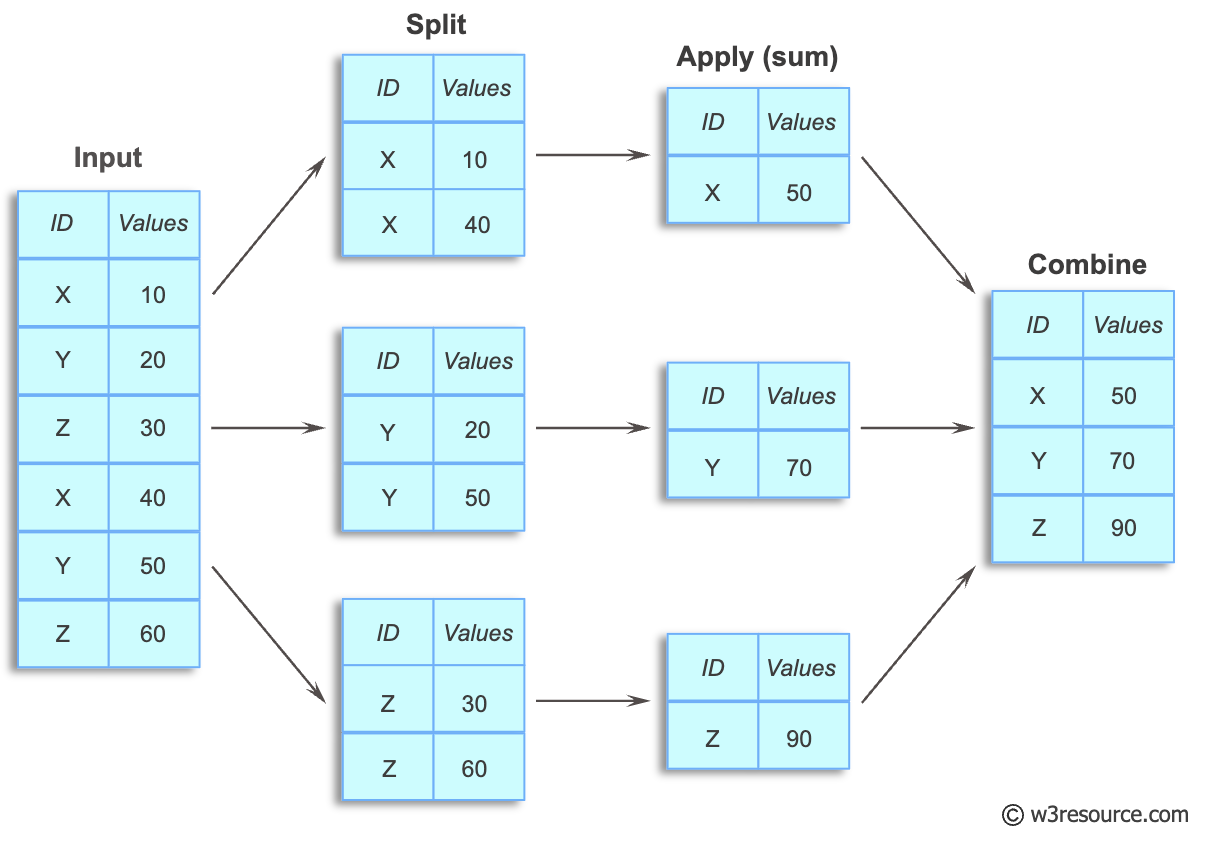

<br>

## Groupby Basic Syntax

```python
df.groupby("column")["target_column"].aggregation()
```

- `"column"` — the column to group by  
- `"target_column"` — the column to aggregate  
- `aggregation()` — the function to apply (e.g. `sum()`, `mean()`, `count()`)

<br>

In [2]:
# Example: calculate total sales per category

superstore.groupby("Category")["Sales"].sum()


Category
Furniture          7.791030e+05
Office Supplies    1.046307e+06
Technology         1.112679e+06
Name: Sales, dtype: float64

In [3]:
# Note: to display float values as standard decimals instead of scientific notation,
# you can set the Pandas global float format like this:
#
# pd.options.display.float_format = '{:,.2f}'.format
#

#
# If you don't want to change the global settings, 
# you can apply the formatting directly to your groupby result using .map():
#
# superstore.groupby("Category")["Sales"].sum().map("{:,.2f}".format)

<br>

## Common Aggregations

The most common aggregation functions are `min`, `max`, `mean`, `sum`, `count`, `size`.

`count` vs `size`:
- `count`: counts the number of non-missing (NaN) values. Unlike the total number of rows, it ignores missing data.
- `size`: counts the total number of rows, including rows with missing values.

In [4]:
# Total sales per category
print("\n\nTotal sales per category:\n")
print(superstore.groupby("Category")["Sales"].sum())

# Average profit per category
print("\n\nAverage profit per category:\n")
print(superstore.groupby("Category")["Profit"].mean())

# Number of orders per segment
print("\n\nNumber of orders per segment:\n")
print(superstore.groupby("Segment")["Order ID"].count())




Total sales per category:

Category
Furniture          7.791030e+05
Office Supplies    1.046307e+06
Technology         1.112679e+06
Name: Sales, dtype: float64


Average profit per category:

Category
Furniture          45.869513
Office Supplies    24.238419
Technology         75.535423
Name: Profit, dtype: float64


Number of orders per segment:

Segment
Consumer       5186
Corporate      3077
Home Office    1737
Name: Order ID, dtype: int64


<br>

## `agg()`

`agg()` lets you apply **multiple aggregations at once**, and optionally to **multiple columns**.


In [5]:
# Multiple aggregations on one column
superstore.groupby("Category")["Sales"].agg(["sum", "mean", "count"])


,sum,mean,count
Category,,,
Furniture,7.791030e+05,519.055996,1501
Office Supplies,1.046307e+06,158.796027,6589
Technology,1.112679e+06,582.554444,1910


In [6]:
# Different aggregations on different columns
superstore.groupby("Category").agg(
    total_sales=("Sales", "sum"),
    avg_profit=("Profit", "mean"),
    num_orders=("Order ID", "count")
)


,total_sales,avg_profit,num_orders
Category,,,
Furniture,7.791030e+05,45.869513,1501
Office Supplies,1.046307e+06,24.238419,6589
Technology,1.112679e+06,75.535423,1910


<br>

## Grouping by Multiple Columns

Pass a list of columns to `groupby` to create groups based on the combination of their values.


In [7]:
# Total sales broken down by region AND category
superstore.groupby(["Region", "Category"])["Sales"].sum()


Region   Category       
Central  Furniture          470359.3095
         Office Supplies    597662.9850
         Technology         652530.3240
North    Furniture          161903.6580
         Office Supplies    214036.3530
         Technology         249634.9740
South    Furniture          146840.0820
         Office Supplies    234607.6860
         Technology         210513.6900
Name: Sales, dtype: float64

<br>

## `as_index=False`

By default, the columns you group by become the row index of the result. Use `as_index=False` to keep them as regular columns instead, resulting in a flat DataFrame — which is usually easier to work with.

A flat DataFrame is a standard spreadsheet-like table where all data lives in regular columns, and rows are simply numbered -e.g. 0, 1, 2, ....

In [8]:
# Default behavior — Region and Category become the index

df_1 = superstore.groupby(["Region", "Category"])["Sales"].sum()

display(df_1)

# we can also check the index and columns:
# display(list(df_1.index))
# display(list(df_1.columns)) # AttributeError: 'Series' object has no attribute 'columns'


Region   Category       
Central  Furniture          470359.3095
         Office Supplies    597662.9850
         Technology         652530.3240
North    Furniture          161903.6580
         Office Supplies    214036.3530
         Technology         249634.9740
South    Furniture          146840.0820
         Office Supplies    234607.6860
         Technology         210513.6900
Name: Sales, dtype: float64

In [9]:

# With "as_index=False" — Region and Category stay as regular columns

df_2 = option_1 = superstore.groupby(["Region", "Category"], as_index=False)["Sales"].sum()

display(df_2)
display(list(df_2.columns))
display(list(df_2.index))


,Region,Category,Sales
0,Central,Furniture,470359.3095
1,Central,Office Supplies,597662.9850
2,Central,Technology,652530.3240
3,North,Furniture,161903.6580
4,North,Office Supplies,214036.3530
5,North,Technology,249634.9740
6,South,Furniture,146840.0820
7,South,Office Supplies,234607.6860
8,South,Technology,210513.6900


['Region', 'Category', 'Sales']

[0, 1, 2, 3, 4, 5, 6, 7, 8]

<br>

**Why use as_index=False?**

- Easier Plotting: Libraries like Seaborn and Plotly expect your data to be in standard columns. If your data is stuck in the index, plotting it requires extra, clunky steps.

- Simpler Data Manipulation: It is generally much easier to filter, query, and merge DataFrames using regular columns rather than index values.

- Prevents MultiIndex Headaches: If you group by multiple columns (e.g., Company and Year), Pandas creates a complex, nested "MultiIndex." Keeping the DataFrame flat avoids this structural complexity entirely.

- Cleaner Exports: When saving to CSV or Excel, flat DataFrames export cleanly with proper column headers, preventing awkward formatting in your spreadsheets.

💡 Tip: If you forget to use `as_index=False`, you can get the exact same flat result by adding `.reset_index()` to the end of your code:
```py
superstore.groupby("Category")["Sales"].sum().reset_index()
```

In [10]:
# display a box plot for sales by category
import matplotlib.pyplot as plt


<br>
<hr>
<br>

## Practice: Pandas groupby()

Instructions:
- https://gist.github.com/luisjunco/79acbd6ba6f0de9515518d972f2c81c9

Time: 15 min.


<br>
<hr>
<br>

<br>

## Resources

Repo with a lot of exercises to practice Pandas (Pandas Exercises, guipsamora):
- https://github.com/guipsamora/pandas_exercises
- For groupby(), see the section "Grouping"

